# Inspect V-JEPA 2.1 Latents


This notebook loads `skate_latents.npy` / `skate_latents.metadata.json`, summarizes the tensor, and visualizes the latent grid in a few useful ways.


It assumes the extracted tensor has shape `[batch, time, height, width, embed_dim]`, which for your run is `[1, 8, 16, 16, 1024]`.

In [6]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd()
LATENT_NPY = ROOT / "skate_latents.npy"
LATENT_PT = ROOT / "skate_latents.pt"
METADATA_PATH = ROOT / "skate_latents.metadata.json"

def load_latents() -> tuple[np.ndarray, dict]:
    if LATENT_NPY.exists():
        latents = np.load(LATENT_NPY)
    elif LATENT_PT.exists():
        latents = torch.load(LATENT_PT, map_location="cpu").numpy()
    else:
        raise FileNotFoundError("Could not find `skate_latents.npy` or `skate_latents.pt` in the current directory.")

    if not METADATA_PATH.exists():
        raise FileNotFoundError("Could not find `skate_latents.metadata.json` in the current directory.")


    metadata = json.loads(METADATA_PATH.read_text())
    return latents, metadata

def flatten_latents(latents: np.ndarray) -> np.ndarray:
    return latents.reshape(-1, latents.shape[-1])

def pca_project(features: np.ndarray, n_components: int = 3) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    centered = features - features.mean(axis=0, keepdims=True)
    u, s, vt = np.linalg.svd(centered, full_matrices=False)
    coords = centered @ vt[:n_components].T
    explained = (s[:n_components] ** 2) / np.maximum((s ** 2).sum(), 1e-12)
    return coords, vt[:n_components], explained

def minmax_scale(values: np.ndarray) -> np.ndarray:
    mins = values.min(axis=0, keepdims=True)
    maxs = values.max(axis=0, keepdims=True)
    return (values - mins) / np.maximum(maxs - mins, 1e-12)

In [7]:
latents, metadata = load_latents()
print("Latent tensor shape:", latents.shape)
print("Latent dtype:", latents.dtype)
print("Model:", metadata["model"])
print("Device used for extraction:", metadata["device"])
print("Raw token shape:", metadata["raw_token_shape"])
print("Frame indices:", metadata["frame_indices"])

batch, time_steps, grid_h, grid_w, embed_dim = latents.shape
assert batch == 1, f"Expected batch size 1, got {batch}"
features = flatten_latents(latents)
norms = np.linalg.norm(features, axis=1)

print()
print("Per-patch norm summary")
print("  mean:", float(norms.mean()))
print("  std :", float(norms.std()))
print("  min :", float(norms.min()))
print("  max :", float(norms.max()))

Latent tensor shape: (1, 8, 24, 24, 1024)
Latent dtype: float32
Model: vit_large_384
Device used for extraction: mps
Raw token shape: [1, 4608, 1024]
Frame indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

Per-patch norm summary
  mean: 64.48307037353516
  std : 5.356979846954346
  min : 42.5789794921875
  max : 74.40287780761719


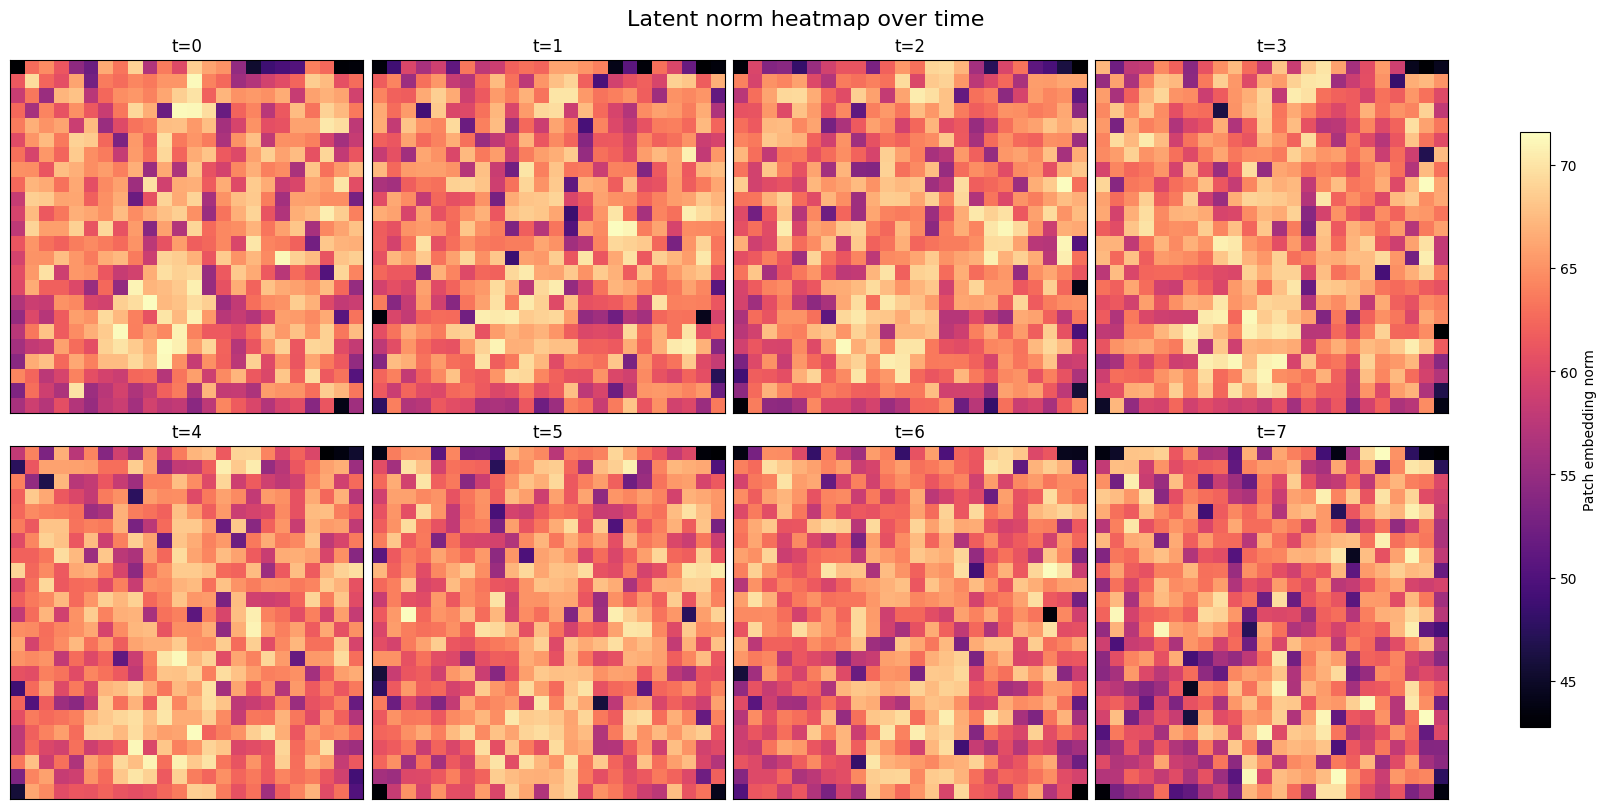

In [8]:
patch_norms = np.linalg.norm(latents[0], axis=-1)
fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)
for time_index, axis in enumerate(axes.flat):
    image = axis.imshow(patch_norms[time_index], cmap="magma")
    axis.set_title(f"t={time_index}")
    axis.set_xticks([])
    axis.set_yticks([])

fig.colorbar(image, ax=axes, shrink=0.8, label="Patch embedding norm")
fig.suptitle("Latent norm heatmap over time", fontsize=16)
plt.show()

Explained variance by first 3 principal components:
  PC1: 0.1081
  PC2: 0.0714
  PC3: 0.0611


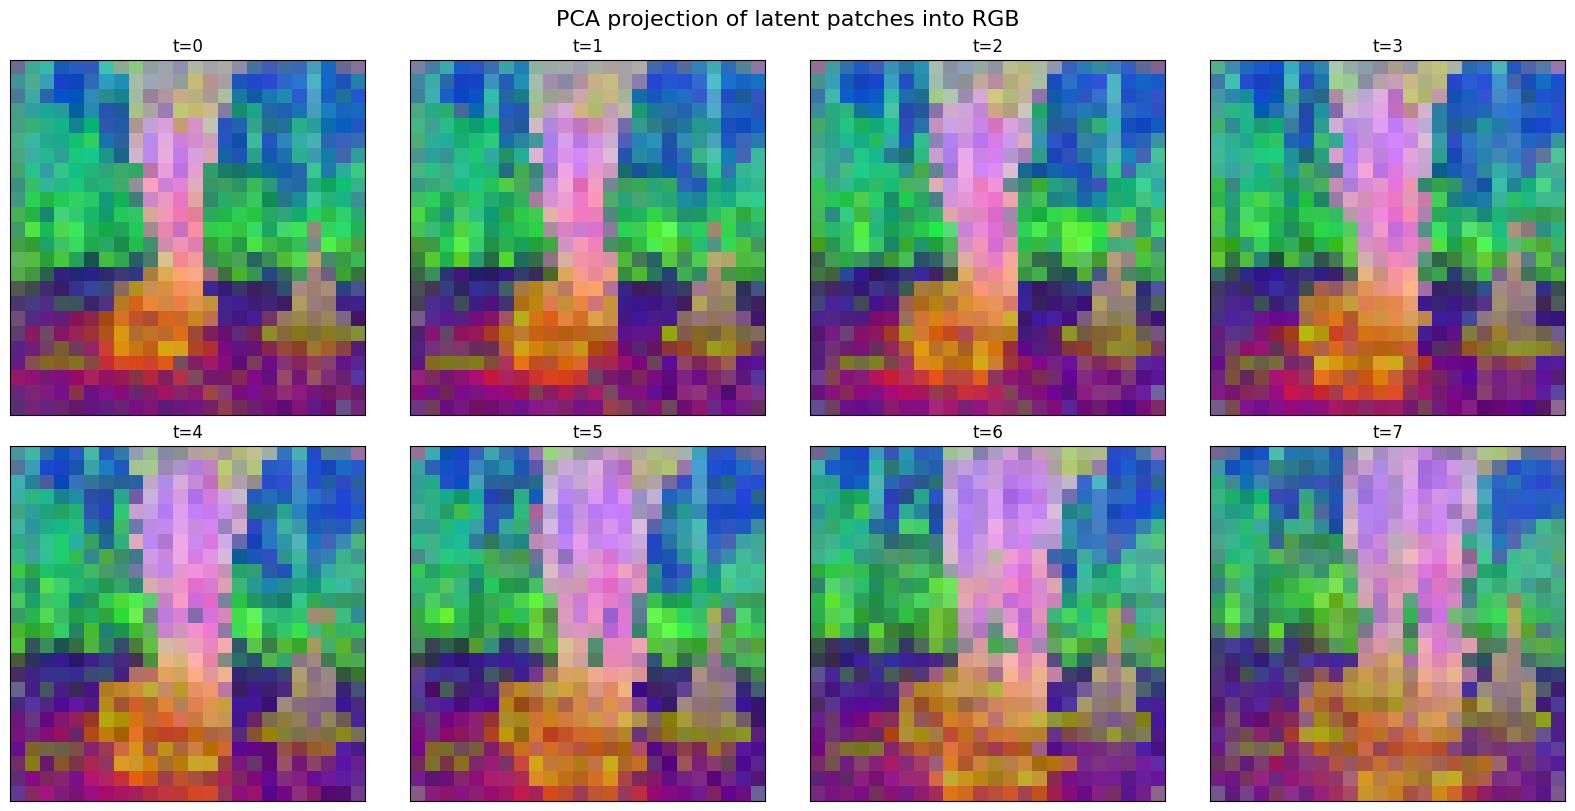

In [12]:
coords, components, explained = pca_project(features, n_components=3)
rgb = minmax_scale(coords).reshape(time_steps, grid_h, grid_w, 3)
print("Explained variance by first 3 principal components:")

for idx, value in enumerate(explained, start=1):
    print(f"  PC{idx}: {value:.4f}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)

for time_index, axis in enumerate(axes.flat):
    axis.imshow(rgb[time_index])
    axis.set_title(f"t={time_index}")
    axis.set_xticks([])
    axis.set_yticks([])

fig.suptitle("PCA projection of latent patches into RGB", fontsize=16)
plt.show()

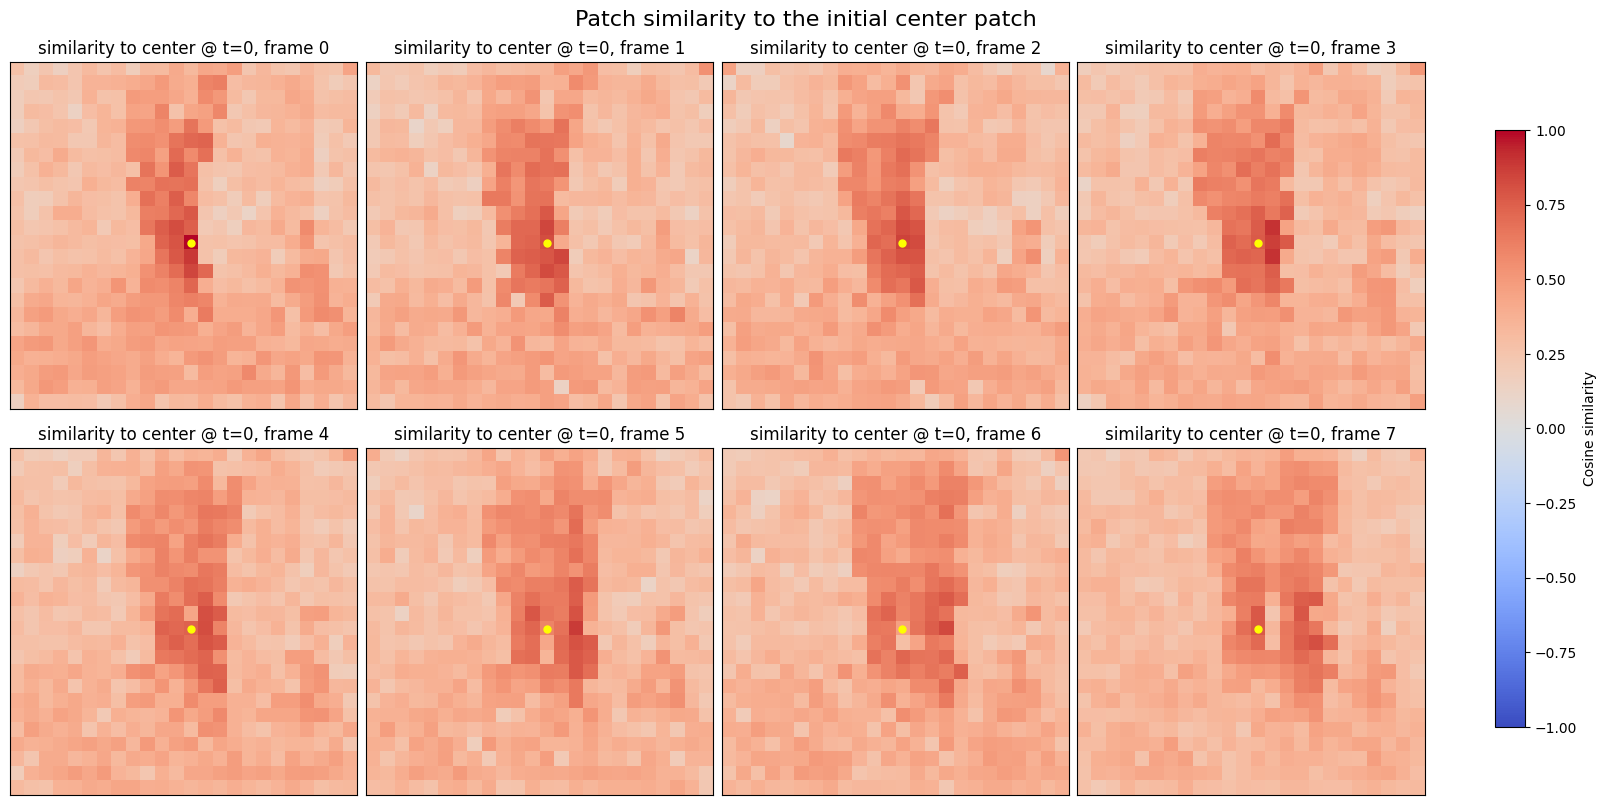

In [10]:
center_row = grid_h // 2
center_col = grid_w // 2
reference = latents[0, 0, center_row, center_col]
reference = reference / np.maximum(np.linalg.norm(reference), 1e-12)

similarity_maps = np.empty((time_steps, grid_h, grid_w), dtype=np.float32)

for time_index in range(time_steps):
    patches = latents[0, time_index]
    patch_norm = np.linalg.norm(patches, axis=-1, keepdims=True)
    normalized = patches / np.maximum(patch_norm, 1e-12)
    similarity_maps[time_index] = np.einsum("hwd,d->hw", normalized, reference)


fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)

for time_index, axis in enumerate(axes.flat):
    image = axis.imshow(similarity_maps[time_index], cmap="coolwarm", vmin=-1, vmax=1)
    axis.scatter([center_col], [center_row], color="yellow", s=25)
    axis.set_title(f"similarity to center @ t=0, frame {time_index}")
    axis.set_xticks([])
    axis.set_yticks([])

fig.colorbar(image, ax=axes, shrink=0.8, label="Cosine similarity")
fig.suptitle("Patch similarity to the initial center patch", fontsize=16)
plt.show()